In [ ]:
import sympy
from sympy import S, solve, Matrix, diff, plot, simplify, factor
from sympy import log as Log
from sympy import sin as Sin
from sympy import cos as Cos
from sympy.plotting import plot3d
from sympy.geometry import Point
import numpy as np
from sympy import S, Symbol, symbols, Function, dsolve, solveset, plot_implicit, integrate, diff, plot
from sympy import exp as Exp
from sympy import pi as Pi
import matplotlib.pyplot as plt
%matplotlib inline

## Занятие 16
## Математический анализ
## Градиент функции нескольких переменных, производная по направлению, касательная плоскость.

    
### Задание 1
Найти градиент функции $z=x^2-xy-2y^2$ в произвольной точке и в точке М(1,2). Вычислить производную  в направлении, составляющем с положительным направлением оси ОХ угол 60 градусов, в точке М(1,2).

In [ ]:
from sympy.abc import x, y

In [ ]:
def f(x, y):
    return x**2 - x*y - 2*y**2
def grad_f(f, *var):
    return Matrix([f(*var).diff(variable) for variable in var])
grad_f(f, x, y)

Matrix([
[ 2*x - y],
[-x - 4*y]])

In [ ]:
def grad_f_point(f, var_dict):
    return grad_f(f, *var_dict.keys()).subs(var_dict)
grad1 = grad_f_point(f, {x: 1, y: 2})
theta = 60 * (Pi / 180)
display(grad1)
display(grad1.dot(Matrix([Cos(theta), Sin(theta)])))

Matrix([
[ 0],
[-9]])

-9*sqrt(3)/2

###  Задание 2.
Поверхность задана уравнением $z = \frac{x^2}{2} - y^2$. Составить уравнение касательной плоскости и нормали в точке $М(2, -1, 1)$. Изобразить на графике.

In [ ]:
from sympy.abc import z
M = Point(2, -1, 1)
dictM = {x: M.x, y: M.y, z: M.z}
f = x**2 / 2 - y**2
fdx, fdy = [f.diff(p).subs(dictM) for p in [x, y]]
display(fdx, fdy)
planeM = sympy.Eq(z - M.z, fdx*(x - M.x) + fdy*(y - M.y))
norm_line = sympy.Eq(sympy.Eq((x - M.x)/fdx, (y - M.y)/fdy, evaluate=False),
                     (z - M.z)/(-1), evaluate=False)
display(planeM)
display(norm_line)

2

2

Eq(z - 1, 2*x + 2*y - 2)

Eq(Eq(x/2 - 1, y/2 + 1/2), 1 - z)

Eq(z, 2*x + 2*y - 1)

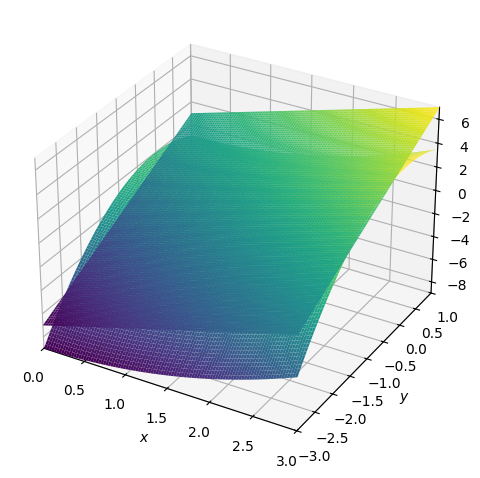

In [ ]:
zz= solve(planeM, z)[0]
display(sympy.Eq(z, zz))
plot3d(zz, f, (x, 0, 3), (y, -3, 1))

###  Задание 3.
Поверхность задана уравнением $3xyz - z^3 = a^3$. Составить уравнение касательной плоскости и нормали к поверхности в точке $x = 0$, $y = a$. Рекомендуется разложить на множители левую часть уравнения касательной плоскости и затем записать ее в более простом виде, считая $a \neq 0$:

In [ ]:
from sympy.abc import a

In [ ]:
dictM = {x: M.x, y: M.y, z: M.z}
F = 3*x*y*z - z**3 - a**3
z_0 = solve(F.subs({x: 0, y: a}), z)[0]
Fdx = F.diff(x).subs({x: 0, y: a, z: z_0})
Fdy = F.diff(y).subs({x: 0, y: a, z: z_0})
Fdz = F.diff(z).subs({x: 0, y: a, z: z_0})
display(Fdx, Fdy, Fdz)

-3*a**2

0

-3*a**2

In [ ]:
plane_equation = sympy.Eq(Fdx * (x - 0) + Fdy * (y - a) + Fdz * (z - z_0), 0)
plane_simplified = sympy.collect(plane_equation.lhs, z)

normal_line = sympy.Eq((x - 0) / Fdx, (y - a) / Fdy)
normal_line = sympy.Eq(normal_line.lhs, (z - z_0) / Fdz)

display(plane_equation)
display(plane_simplified)
display(normal_line)

Eq(-3*a**2*x - 3*a**2*(a + z), 0)

-3*a**2*x - 3*a**2*(a + z)

Eq(-x/(3*a**2), -(a + z)/(3*a**2))

## Линейные ОДУ второго порядка с постоянными коэффициентами
## Задание № 4
Решить аналитически ОДУ с разделяющимися переменными
$$
y'=\ln(x+2)e^{2-y}.
$$
Найти общий интеграл.

In [ ]:
from sympy import ln as Ln

In [ ]:
x, y = symbols('x y', real=True)
C = symbols('C')

ODE1 = sympy.Eq(integrate(Exp(y - 2), y), integrate(Ln(x + 2), x) + C)
ODE1

Eq(exp(y - 2), C + x*log(x + 2) - x + 2*log(x + 2))

## Задание № 5
Решить аналитически задачу Коши
$$
y^3y'=\frac{1}{1+x^2},\qquad y(0)=1.
$$
Найти общий интеграл, учесть начальное условие.
Построить график $y$, пользуясь plot_implicit.

In [61]:
x, y, C = symbols('x y C', real=True)
ODE2 = sympy.Eq(integrate(y**3, y), integrate(S(1 )/ (1 + x**2), x) + C)
display(ODE2)

Eq(y**4/4, C + atan(x))

In [62]:
x0y0 = {x: 0, y: 1}
Cval = solveset(sympy.Eq(ODE2.lhs.subs(x0y0), ODE2.rhs.subs(x0y0)), C)
Cval

{1/4}

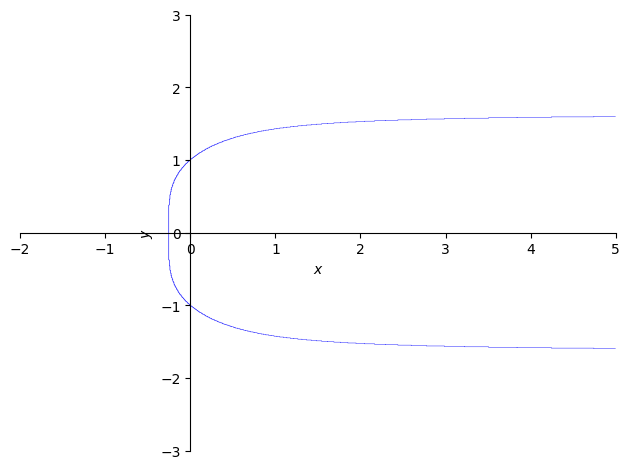

In [63]:
plot_implicit(sympy.Eq(ODE2.lhs, ODE2.rhs.subs(C, *Cval)), (x, -2, 5), (y, -3, 3))

### Индивидуальное задание. Вариант №191
Поверхность задана уравнением $f$. Составить уравнение касательной плоскости и нормали в точке $(R\cos\alpha,R\sin\alpha,R)$.  Изобразить на графике при $R=$ значение из ИДЗ, $\alpha=$значение из ИДЗ.

In [ ]:
x, y = symbols('x y')
z = sympy.Function('z')(x, y)

M = Point(-1, 2, S(-2)/29)
dictM = {x: M.x, y: M.y, z: M.z}
f = -x*z / 2 + x + 3*y*z + 2*y/3
fdx, fdy = [f.diff(p).subs(dictM) for p in [x, y]]
planeM = sympy.Eq(z - M.z, fdx * (x - M.x) + fdy * (y - M.y))
norm_line = sympy.Eq(sympy.Eq((x - M.x)/fdx, (y - M.y)/fdy, evaluate=False),(z - M.z)/(-1), evaluate=False)

zz = solve(planeM, z)[0]

display(planeM)
display(norm_line)
display(sympy.Eq(z, zz))

Eq(z(x, y) + 2/29, (x + 1)*(13*Subs(Derivative(-2/29, x), x, -1)/2 + 30/29) + (y - 2)*(13*Subs(Derivative(-2/29, y), y, 2)/2 + 40/87))

Eq(Eq((x + 1)/(13*Subs(Derivative(-2/29, x), x, -1)/2 + 30/29), (y - 2)/(13*Subs(Derivative(-2/29, y), y, 2)/2 + 40/87)), -z(x, y) - 2/29)

Eq(z(x, y), 30*x/29 + 40*y/87 + 4/87)

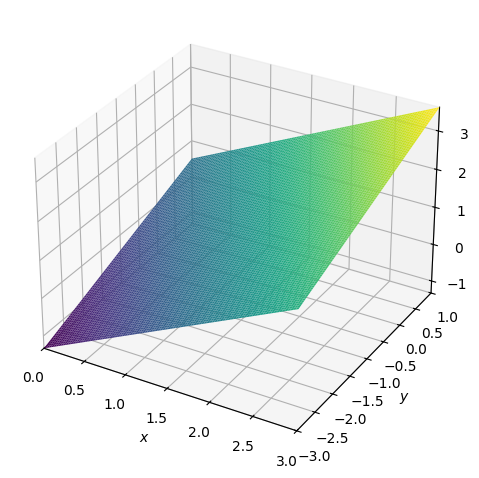

In [ ]:
plot3d(zz, (x, 0, 3), (y, -3, 1))